# Example of usage of open_save code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [8]:
R = 2.
r = 0.5

NGSOLVE = True

lc = 1.

if NGSOLVE:
    from cases.open_space.ngsolve_geometries import CleanCircle, AnularDomain, Regions
    mesh = AnularDomain(R=R, r=r, verbosity=0, lc=lc)
    # mesh = CleanCircle(R=R, verbosity=0, lc=lc)
else:
    raise NotImplementedError
    from cases.open_space.gmsh_geometries import CleanWaveguide, WaveguideRegions
    mesh = CleanWaveguide(R=R, H=H, verbose=True, lc=lc)


In [9]:
mesh.n_triangles

120

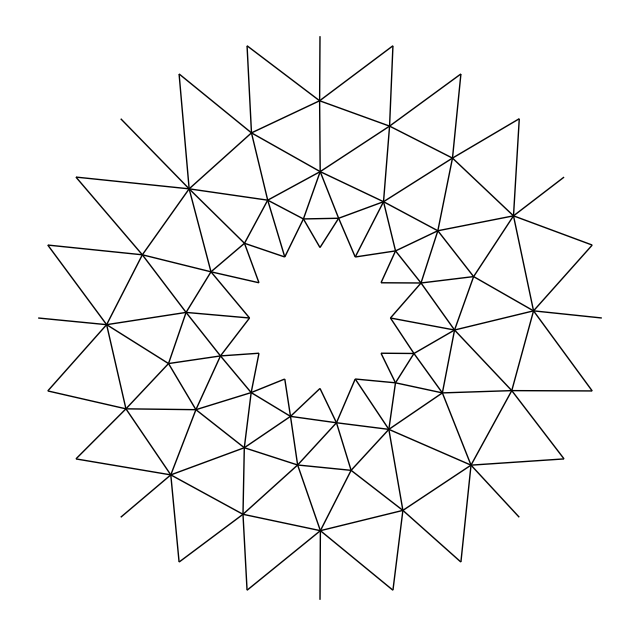

In [10]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [11]:
list(Regions)

[<Regions.OMEGA: 'Omega'>,
 <Regions.SIGMA: 'Sigma'>,
 <Regions.d_Omega: 'd_Omega'>]

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [12]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [13]:
import numpy as np
data = {"d_inc": np.array([-1., 0.])}
boundary_conditions = {Regions.SIGMA: NtDBC(truncating_radius=R, data=None), Regions.d_Omega: DirichletBC(data=data)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [14]:
from trefftz.dg.serial_kernels import UltraWeakKernel, CircularDirichletKernel


as well as specific ones (for a circular NtD map):

In [15]:
from cases.open_space.kernels import NtDLocal_circle, NtDNonLocal_circle

Now the numerics (the configuration of kernels) is almost a dictionary:

In [16]:
from trefftz.dg.assemblers import SerialNumerics
n = 0
numerics = SerialNumerics(interior_kernel=UltraWeakKernel(a=0.5, b=0.5),
                          local_boundary_kernels={NtDBC: NtDLocal_circle(R=R, d_2=0.5, n=1), DirichletBC: CircularDirichletKernel(a=0.5, R=R, data=data)},
                          nonlocal_boundary_kernels= {NtDBC: NtDNonLocal_circle(R=R, d_2=0.5, n=1, NtD_modes=5)})

We should also choose a local basis

In [17]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=5)

and an assembler:

In [18]:
basis.N_DOF

600

In [19]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [20]:
assembler._regions_RHS_term

[<Regions.d_Omega: 'd_Omega'>]

so we can set the problem:

In [21]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler)

In [22]:
A = P.assemble_LHS()

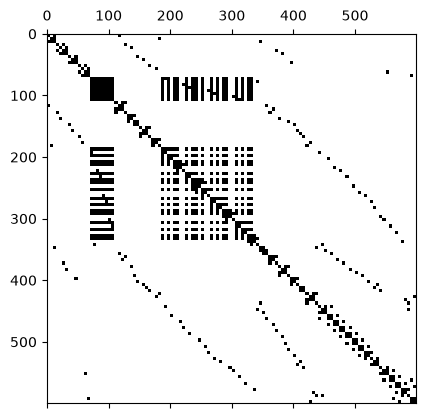

In [23]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [24]:
b = P.assemble_RHS()

In [25]:
P.solve()

In [26]:
P.u_h.coefficients.reshape((-1,3))

array([[-6.31593900e-01+7.07908603e-02j, -4.15316030e+00-1.62815935e+00j,
        -9.30480198e+00+1.69771949e+00j],
       [ 1.77180133e+00-4.57666436e-01j, -2.40036752e-02-1.49777511e+00j,
        -7.90405608e+00+2.01230961e+00j],
       [-1.56256140e+00-9.53396873e+00j, -7.03126547e+00+2.67934652e+00j,
         9.11393520e-01+2.87481197e+00j],
       [ 2.43372911e+00+6.29054216e-01j, -3.59267476e+00+3.52581199e+00j,
        -2.71644888e+00-1.32802206e+00j],
       [-4.54449260e+00-2.12555358e-01j, -1.82057959e-01-6.95038199e-01j,
         2.34082307e+00-4.79419996e-01j],
       [-8.37201077e-01+7.84377744e-01j,  1.66138920e+00+2.49777388e+00j,
         2.58738100e+00+2.10689718e+00j],
       [ 2.46599382e+00+6.89472258e-01j,  1.41933465e+00+8.03290191e-01j,
        -2.18416948e-01-7.28157065e-01j],
       [-1.36916079e+00+9.40939545e-01j,  7.18258629e+00-1.03606733e+01j,
        -5.95436935e+00-1.40312127e+00j],
       [ 4.95058507e-01+1.34393922e+00j, -1.42003097e+00-7.77616265e-01j

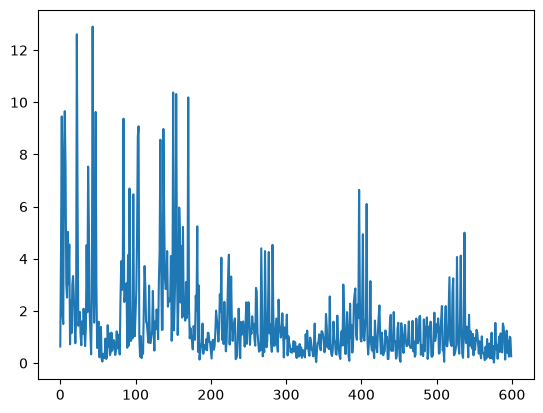

In [27]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [34]:
import numpy as np
N = 200
r_min = r
rs = np.linspace(r, R, N)
theta = np.linspace(0, 2*np.pi, N)
Rs, Theta = np.meshgrid(rs, theta)
X = Rs*np.cos(Theta)
Y = Rs*np.sin(Theta)
x = X.ravel()
y = Y.ravel() 
z = P.u_h(x, y)

/home/manuel/Documentos/Trefftz/.venv/lib/python3.12/site-packages/matplotlib/collections.py:1115: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
/tmp/ipykernel_72694/4230987361.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x,y,np.real(z),cmap="viridis")


(np.float64(-2.19973831798708),
 np.float64(2.200124608347208),
 np.float64(-2.199931463167144),
 np.float64(2.199931463167144))

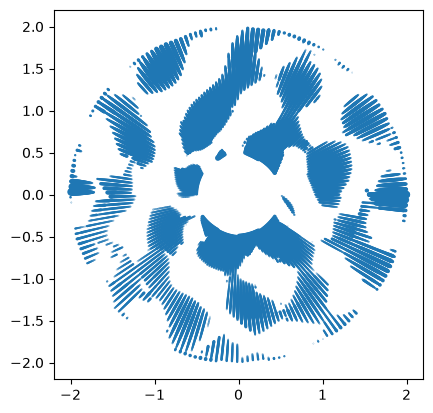

In [40]:
import matplotlib.pyplot as plt
plt.scatter(x,y,np.real(z),cmap="viridis")
plt.axis("square")